In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [3]:
file_path = 'student-mat.csv'
df = pd.read_csv(file_path, delimiter=';')

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [5]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

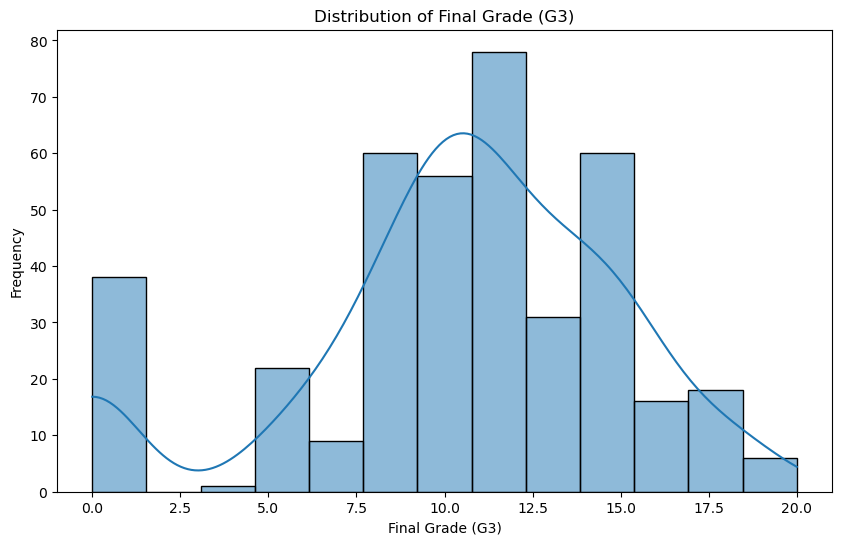

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(df['G3'], kde=True)
plt.title('Distribution of Final Grade (G3)')
plt.xlabel('Final Grade (G3)')
plt.ylabel('Frequency')
plt.show()

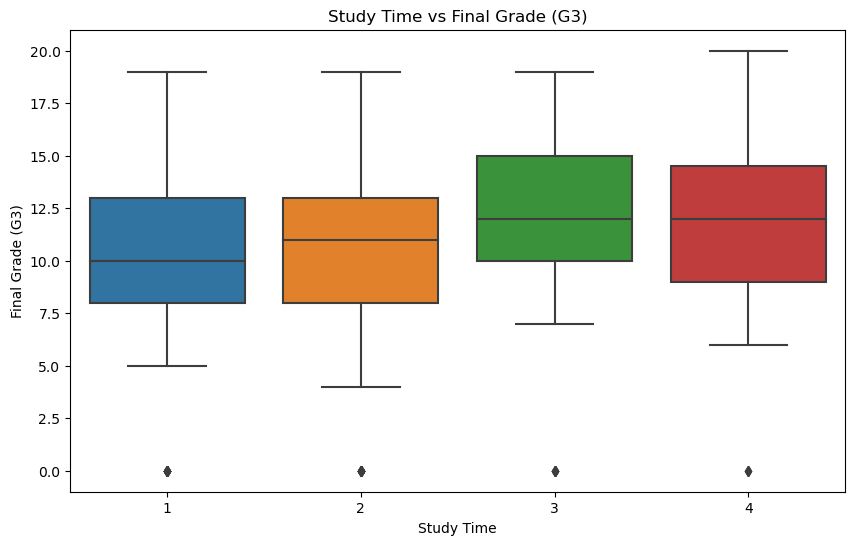

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='studytime', y='G3', data=df)
plt.title("Study Time vs Final Grade (G3)")
plt.xlabel("Study Time")
plt.ylabel("Final Grade (G3)")
plt.show()

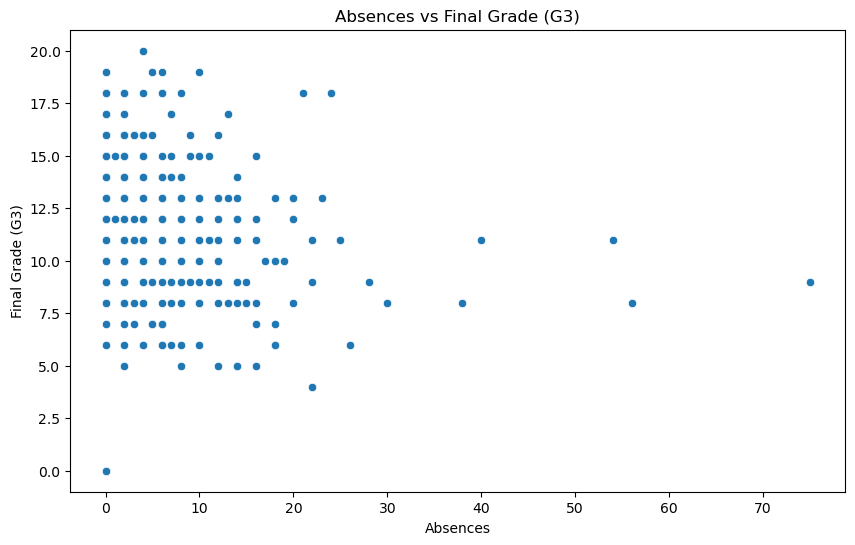

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='absences', y='G3', data=df)
plt.title("Absences vs Final Grade (G3)")
plt.xlabel("Absences")
plt.ylabel("Final Grade (G3)")
plt.show()

Hypothesis 1:Increasing study time improves students' final grades.

In [19]:
studytime_groups = [df[df['studytime'] == time]['G3'] for time in sorted(df['studytime'].unique())]

In [20]:
anova_stat, anova_p_val = stats.f_oneway(*studytime_groups)
print(f"ANOVA Test: F-statistic = {anova_stat}, p-value = {anova_p_val}")

ANOVA Test: F-statistic = 1.7278351054436039, p-value = 0.1607228096836598


In [21]:
if anova_p_val < 0.05:
    print("Hypothesis 1 supported: There is a significant difference in final grades based on study time.")
else:
    print("Hypothesis 1 not supported: No significant difference in final grades based on study time.")

Hypothesis 1 not supported: No significant difference in final grades based on study time.


Hypothesis 2: Higher absences are associated with lower final grades.

In [22]:
corr_absences, p_val_corr_absences = stats.pearsonr(df['absences'], df['G3'])
print(f"Pearson Correlation between Absences and Final Grades: correlation = {corr_absences}, p-value = {p_val_corr_absences}")

Pearson Correlation between Absences and Final Grades: correlation = 0.034247316150069325, p-value = 0.4973317955435264


In [23]:
if p_val_corr_absences < 0.05:
    print("Hypothesis 2 supported: There is a significant negative correlation between absences and final grades.")
else:
    print("Hypothesis 2 not supported: No significant correlation between absences and final grades.")


Hypothesis 2 not supported: No significant correlation between absences and final grades.


Documentation and Reporting

Key Features：

Study Time vs Final Grades: A boxplot was used to display the relationship between study time (studytime) and final grades (G3). This visualization helped us observe if students with longer study times generally achieved higher grades.

Absences vs Final Grades: A scatter plot was used to illustrate the relationship between absences (absences) and final grades (G3). This helped us check for any visible trends between absenteeism and academic performance.


Based on the observations, I proposed the following hypotheses:

Hypothesis 1 : Increasing study time improves students' final grades.

Hypothesis 2 : Higher absences are associated with lower final grades.


Testing hypothesis 1:

Using an ANOVA test,I compared final grades across different levels of study time.
Results: F-statistic = 1.73, p-value = 0.16.
Since the p-value is greater than 0.05, we do not have enough evidence to conclude that study time significantly impacts final grades. Thus, Hypothesis 1 is not supported.

Testing hypothesis 2: 

I calculated the Pearson correlation between absences and final grades to determine if there’s a negative association.
Results: Correlation = 0.034, p-value = 0.50.
With a p-value > 0.05 and a very low correlation coefficient, I find no significant correlation between absences and final grades, meaning Hypothesis 2 is not supported.

This analysis suggests that neither study time nor absences are major predictors of academic performance in this dataset. To gain further insight, future studies could explore additional variables, such as family background, extracurricular involvement, or health factors. These might provide a more comprehensive understanding of the factors that influence student success.

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X = df[['studytime', 'absences']]
y = df['G3']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error of the model: {mse}")

Mean Squared Error of the model: 21.962124744774375


The model’s Mean Squared Error (MSE) is around 21.96, which, given that student grades (G3) range from 0 to 20, suggests that our predictions aren’t particularly close to actual values. This high MSE shows that studytime and absences alone don’t explain much of the variation in grades. It aligns with our earlier findings that neither variable has a strong relationship with G3. This suggests that there are likely other, more relevant factors affecting academic performance that aren’t included here.